# Baseline Posterior Inference: Electrical Impedance Tomography

- PDE: $-\nabla \cdot (a \nabla u) = 0$
- Latent dimension: $d_a = 6$ (normalising flow and MCMC dimension), $d_u = 26$ (with boundary encoding)
- Observations: Neumann boundary flux at 124 boundary points

In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "test_idx": t}
    for s, t in itertools.product([42, 123, 7], [0, 1, 2])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
from pathlib import Path

import numpyro

from src.problems.eit import EIT, one_hot_g_l, compute_u_and_grad_eit, mollifier_eit
from src.evaluation.metrics import rmse
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95, nll_score,
    plot_field_comparison, plot_calibration, plot_posterior_gallery,
    plot_posterior_predictive, plot_trace, plot_metrics_table,
    plot_eit_ground_truth, plot_eit_observation_data,
    compute_per_chain_metrics, format_significance_table,
    tune_sigma, recommended_nuts_config, mcmc_reliability_flag,
    chi2_ppc,
    compute_metric_convergence, plot_metric_convergence,
    compute_prior_predictive, build_prior_result,
    plot_std_comparison_generic,
    compute_error_std_correlation,
    plot_uncertainty_investigation,
    load_problem, get_nf_mode, make_log_prior,
    make_numpyro_model,
    run_map_estimation,
    sample_unconditional_prior, decode_posterior_batched,
    run_mcmc, extract_mcmc_diagnostics,
    compute_bootstrap_ci_block,
    build_mcmc_result, save_experiment_result,
    print_per_chain_table, print_dimension_diagnostics, print_cross_seed_summary,
)

SEEDS = [42, 123, 7]
if _task_id is not None: SEEDS = [PARAMETER_GRID[_task_id]["seed"]]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
CHECKPOINT_PATH = Path("../runs/final_eit/weights/best.pt")
TEST_DATA_PATH = "../data/eit/inverse_EIT_in.mat"

problem = EIT(seed=42, test_data_path=TEST_DATA_PATH)
params = load_problem(problem, CHECKPOINT_PATH)
beta_a_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

print(f"Latent dim (coeff): {problem.BETA_SIZE_A}")
print(f"Latent dim (combined): {problem.BETA_SIZE_U}")

Loading data...


  Test: a=(20, 1024, 1), u=[[[ 1.        ]
  [ 0.9797001 ]
  [ 0.9204757 ]
  ...
  [ 0.8746724 ]
  [ 0.761118  ]
  [ 0.6172527 ]]

 [[ 1.        ]
  [ 0.981173  ]
  [ 0.9261911 ]
  ...
  [ 0.3165446 ]
  [ 0.12906456]
  [-0.06325148]]

 [[ 1.        ]
  [ 0.98346853]
  [ 0.9351161 ]
  ...
  [-0.2334332 ]
  [-0.40426344]
  [-0.5620679 ]]

 ...

 [[ 1.        ]
  [ 0.981173  ]
  [ 0.9261911 ]
  ...
  [-0.8738502 ]
  [-0.7647962 ]
  [-0.62749803]]

 [[ 1.        ]
  [ 0.9797001 ]
  [ 0.9204757 ]
  ...
  [ 0.10988297]
  [ 0.30528814]
  [ 0.48864248]]

 [[ 1.        ]
  [ 0.9791928 ]
  [ 0.918509  ]
  ...
  [ 0.918509  ]
  [ 0.9791928 ]
  [ 1.        ]]]
  Boundary points: 124 (left=32, top=31, right=31, bottom=30)
Setting up grids and test functions...


  int_grid: (25, 2), v: (25, 1)
Building models...


  Initialized enc: 113,702 params


  Initialized u: 83,805 params


  Initialized a: 81,805 params


E0612 04:29:34.791155      23 hlo_lexer.cc:443] Failed to parse int literal: 894515288310727292233


  Initialized nf: 15,420 params
Loading checkpoint: ../runs/final_eit/weights/best.pt
  Loaded enc
  Loaded u
  Loaded a
  Loaded nf


Latent dim (coeff): 6
Latent dim (combined): 26


## 2. Prepare Observations

In [4]:
TEST_IDX = 0
if _task_id is not None: TEST_IDX = PARAMETER_GRID[_task_id]["test_idx"]
N_OBS = 124

n_points = problem.get_n_points()

## 3. Inversion Config

In [5]:
inv_config = InversionConfig(
    epochs=200,
    loss_weights=LossWeights(pde=1.0, data=100.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.01),
    scheduler=SchedulerConfig(type='StepLR', step_size=25, gamma=0.25),
)

## 4. Per-Seed Loop


SEED = 123


x_obs (boundary): (1, 124, 2), u_obs (Neumann flux): (1, 124, 1)
Boundary points: 124, g_l = 2


Prior predictive: a_err=0.3198, CRPS=0.7804, cov95=0.9766, CI_width=3.7442, mean_std=1.0653


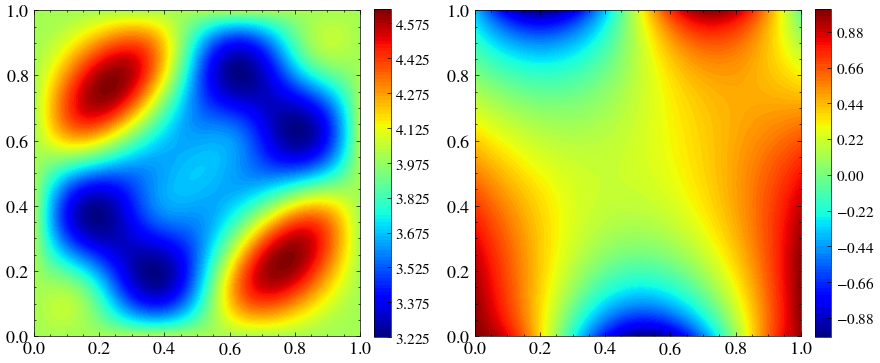

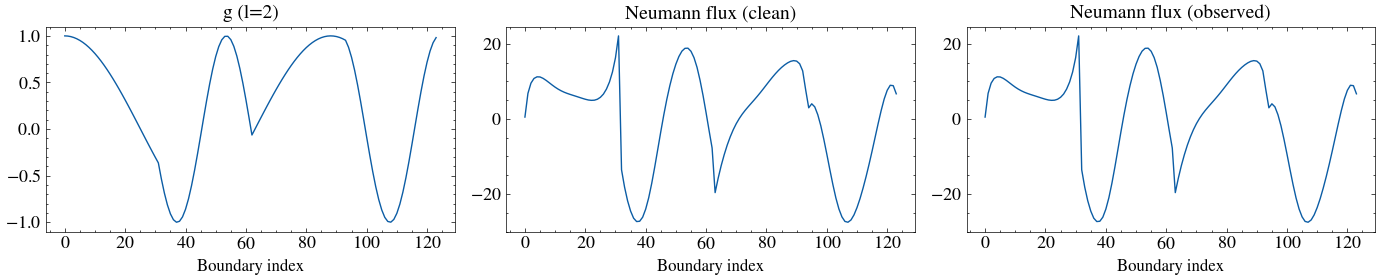

  Inversion grid: n_mesh_or_grid=7, n_grid=25


Loss weights: pde=1.0, data=100.0, target=neumann


Inverting:   0%|          | 0/200 [00:00<?, ?it/s]

Inverting:   0%|          | 1/200 [00:04<14:02,  4.23s/it]

Inverting:  42%|████▏     | 83/200 [00:04<00:04, 26.99it/s]

...

a_pred_all: (8000, 1024), u_pred_all: (8000, 1024)



  EIT — RQ1 Metrics
  MAP RMSE (a)                  : 0.055873
  Posterior Mean RMSE (a)       : 0.004028
  CRPS (a)                      : 0.009677
  Mean 95% CI Width (a)         : 0.101548
  Sharpness (mean std)          : 0.025959
  sigma                         : 0.200000

Calibration:
  Nominal 10% -> Empirical 13.38%
  Nominal 19% -> Empirical 25.29%
  Nominal 29% -> Empirical 40.04%
  Nominal 38% -> Empirical 50.98%
  Nominal 48% -> Empirical 65.72%
  Nominal 57% -> Empirical 76.46%
  Nominal 67% -> Empirical 84.18%
  Nominal 76% -> Empirical 92.19%
  Nominal 86% -> Empirical 97.27%
  Nominal 95% -> Empirical 99.41%


──────────────────────────────────────────────────────────────────────────────────
  RQ1 — Bootstrap CI on Posterior Metrics (EIT)
──────────────────────────────────────────────────────────────────────────────────
  CRPS (a)                                   0.00968  95% CI [0.00958, 0.00978]
  Coverage 95% (a)                           0.99414  95% CI [0.99414, 0.99512]
  CI Width 95% (a)                           0.10155  95% CI [0.10055, 0.10254]
  Sharpness (a)                              0.02596  95% CI [0.02576, 0.02618]
──────────────────────────────────────────────────────────────────────────────────
  Significance: ** p<0.01  * p<0.05  ~ p<0.1  n.s. not significant
  Bootstrap CIs reflect MCMC finite-sample variability, not posterior uncertainty.
──────────────────────────────────────────────────────────────────────────────────



Per-chain consistency:
  Chain      CRPS     Cov95      CI W     Sharp
      1  0.00968  0.9951  0.10026  0.02586
      2  0.00975  0.9941  0.10263  0.02620
      3  0.00952  0.9941  0.10102  0.02563
      4  0.00978  0.9932  0.10150  0.02609


Saved structured result to: /workspace/experiments/results/structured/baseline/eit_2026-06-12T05-13-57_seed123_test1.json


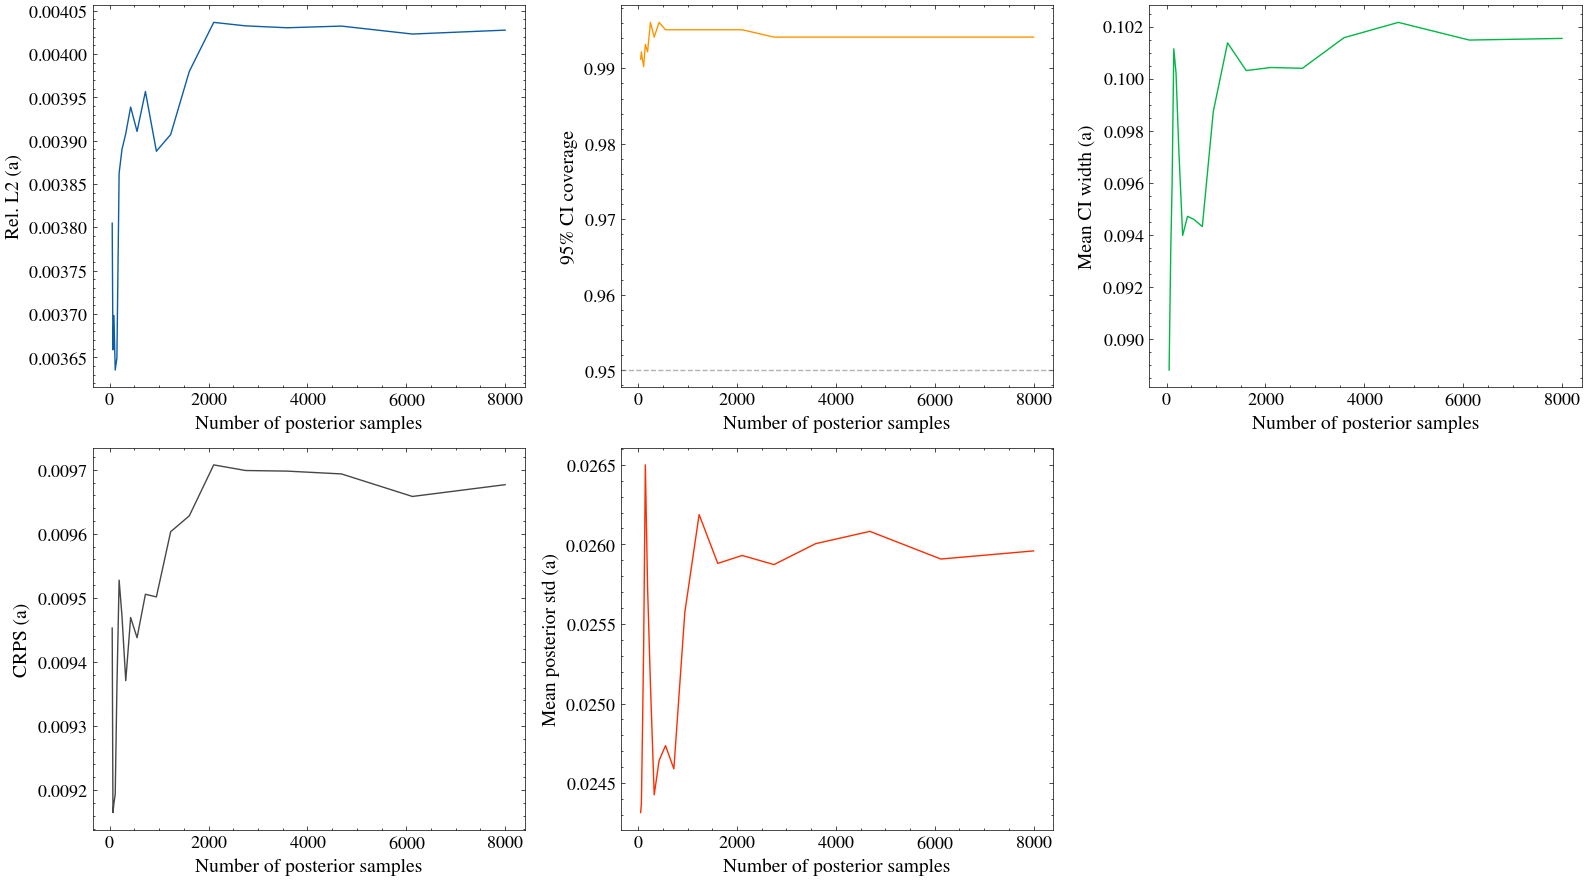

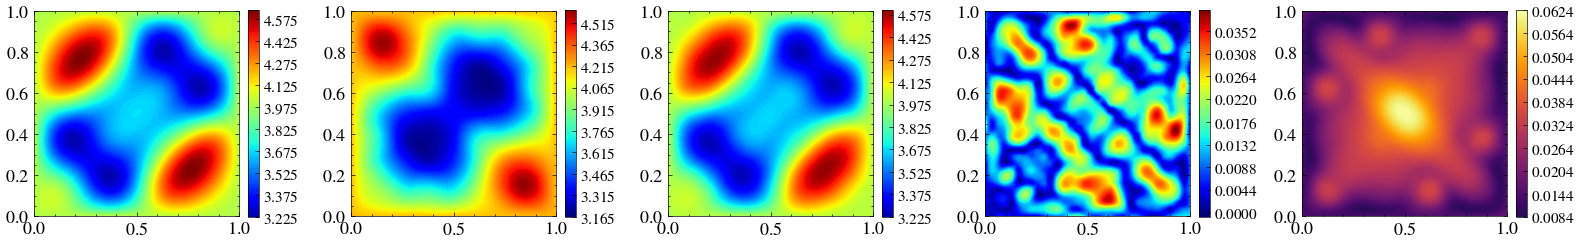

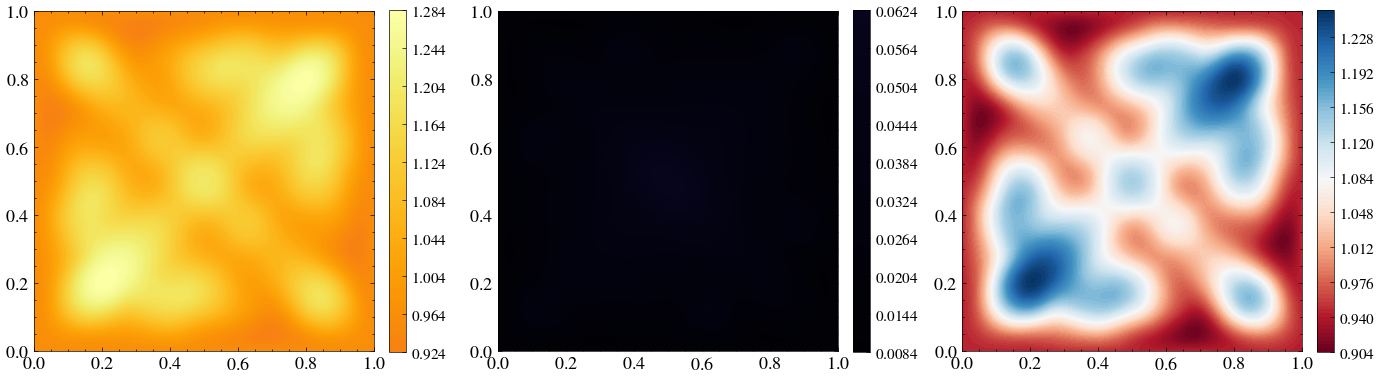

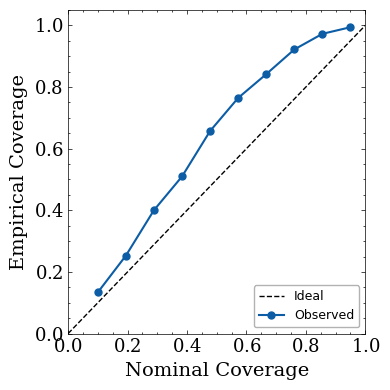

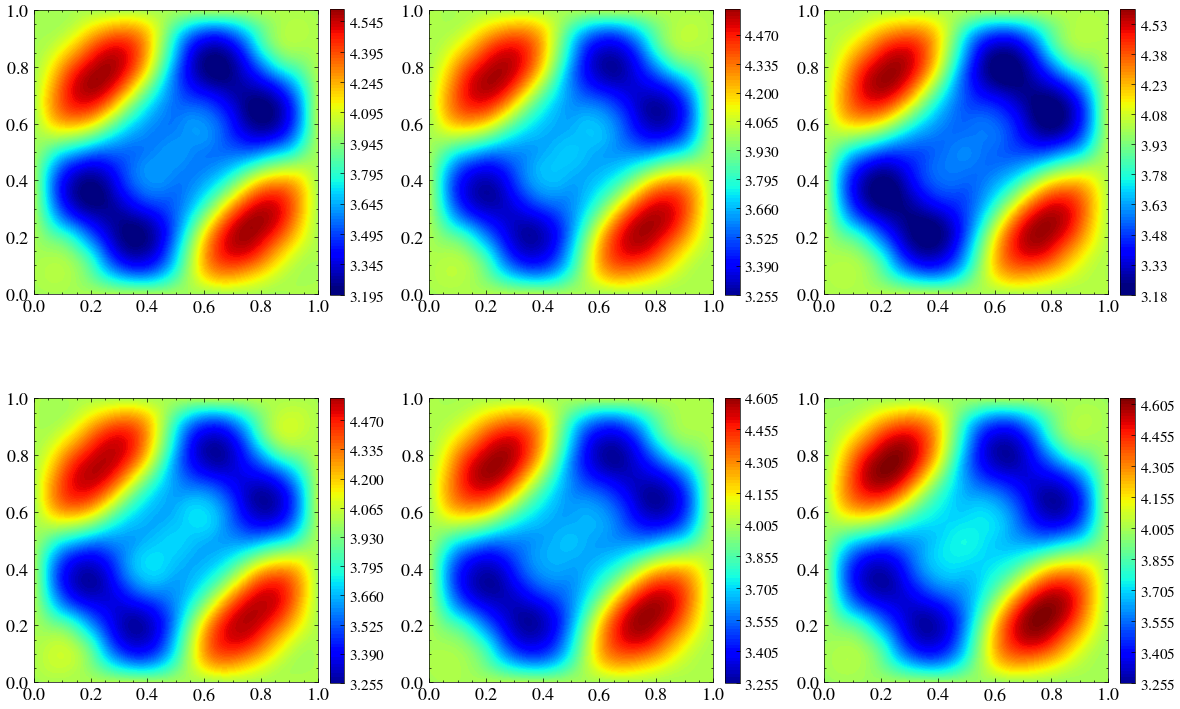

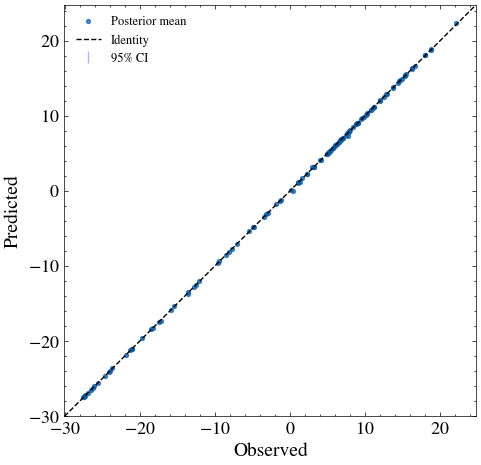

  Chi2 PPC: chi2=19.85, p=1.0000 (df=124)


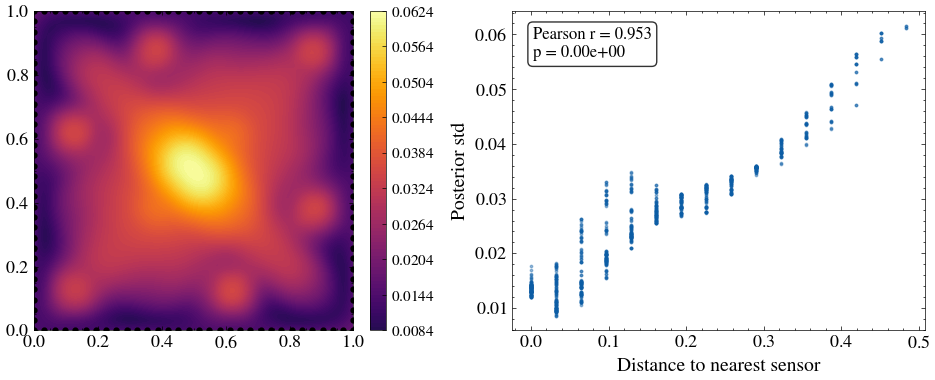

Spearman rho(|error|, std) = 0.255, p = 1.16e-16
Per-dimension diagnostics:
 dim       ESS     R-hat        mean         std
   0    4290.5    1.0002     -0.6496      0.0032
   1    4512.2    0.9998      0.1213      0.0029
   2    6943.4    0.9998     -0.7275      0.0032
   3    5142.0    0.9999      0.8470      0.0024
   4    3533.2    0.9998      0.0550      0.0046
   5    7187.8    1.0001      0.1508      0.0069

Divergences: 2 / 8000 (0.0%)

  RELIABILITY: [PASS] All diagnostics within thresholds


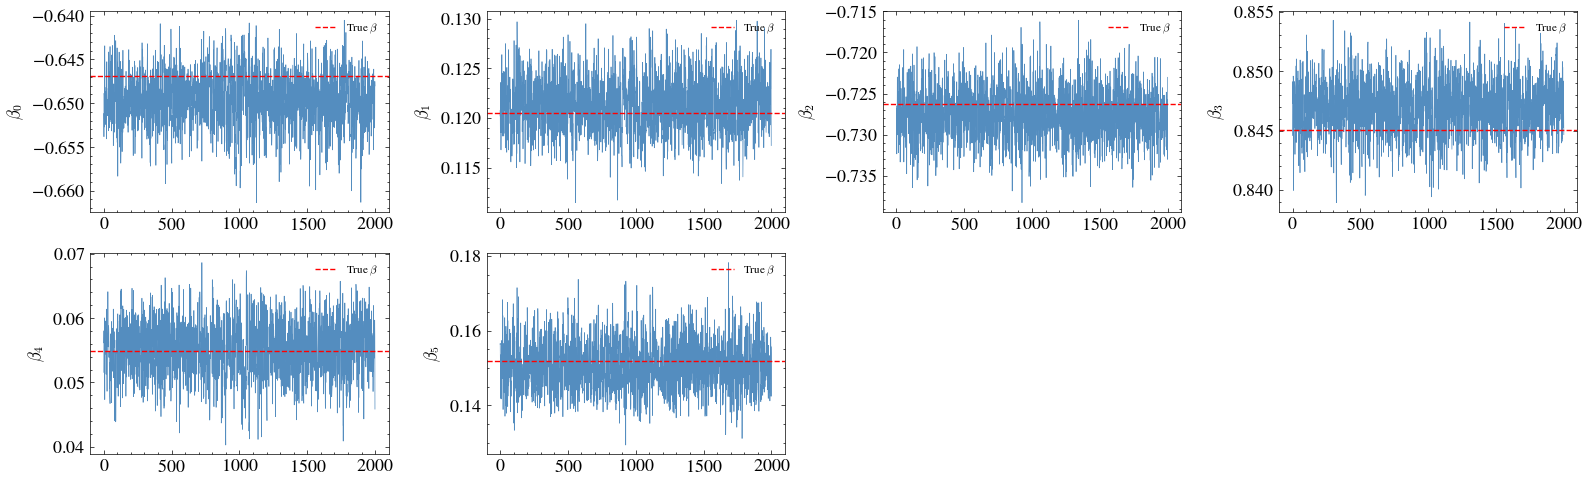

In [6]:
NUM_WARMUP = 5000
NUM_SAMPLES = 2000
NUM_CHAINS = 4
CHAIN_METHOD = 'vectorized'

for SEED in SEEDS:
    print(f"\n{'='*60}")
    print(f"SEED = {SEED}")
    print(f"{'='*60}")

    _t_total_start = time.time()

    FIGURE_DIR = Path(f'figures/baseline_eit/seed_{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    # ### Observations (this seed)

    rng = random.PRNGKey(SEED)
    rng, key = random.split(rng)

    obs_indices = problem.sample_observation_indices(n_points, N_OBS, 'random', key)

    obs_data = problem.prepare_observations(
        sample_indices=[TEST_IDX],
        obs_indices=obs_indices,
    )

    x_full = obs_data['x_full']
    x_obs = obs_data['x_obs']
    u_obs = obs_data['u_obs']
    a_true = obs_data['a_true']
    g_l = obs_data['g_l']
    normals = problem._active_boundary_normals_jax

    u_true = obs_data.get('u_true', None)

    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]

    print(f"x_obs (boundary): {x_obs.shape}, u_obs (Neumann flux): {u_obs.shape}")
    print(f"Boundary points: {x_obs.shape[1]}, g_l = {int(g_l[0, 0])}")

    # ### Prior Predictive Baseline

    a_true_np = np.array(a_true[0, :, 0])
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
    )
    prior_a_std = np.std(prior_a_samples, axis=0)
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}, "
          f"CI_width={prior_metrics['ci_width']:.4f}, mean_std={prior_metrics['mean_std']:.4f}")

    # ### Ground truth and observation plots

    plot_eit_ground_truth(
        np.array(x_full[0]),
        np.array(a_true[0, :, 0]),
        u_true=np.array(u_true[0, :, 0]) if u_true is not None else None,
        save_path=FIGURE_DIR / 'ground_truth.png',
    )

    plot_eit_observation_data(
        x_bd=np.array(x_obs[0]),
        g_l=int(g_l[0, 0]),
        neumann_obs=np.array(u_obs[0, :, 0]),
        save_path=FIGURE_DIR / 'observation_data.png',
    )

    # ### Log-likelihood and NumPyro model (EIT keeps inline log_likelihood_fn)

    def log_likelihood_fn(beta_a, sigma):
        beta_b = beta_a[None, :]
        g_l_onehot = one_hot_g_l(problem._current_g_l)
        beta_u = jnp.concatenate([beta_b, g_l_onehot], axis=-1)
        g_l_scalar = problem._current_g_l[0, 0]
        _, du_vals = compute_u_and_grad_eit(
            params['u'], problem.models['u'],
            x_obs[0], beta_u[0], g_l_scalar
        )
        a_vals = problem.models['a'].apply(
            {'params': params['a']}, x_obs, beta_b
        )[0]
        neumann_pred = a_vals * (du_vals[:, 0] * normals[:, 0] + du_vals[:, 1] * normals[:, 1])
        neumann_obs = u_obs[0, :, 0]
        sq_err = jnp.sum((neumann_pred - neumann_obs) ** 2)
        n = neumann_obs.shape[0]
        return -0.5 * sq_err / (sigma ** 2) - 0.5 * n * jnp.log(2 * jnp.pi * sigma ** 2)

    numpyro_model = make_numpyro_model(d, log_prior_fn, log_likelihood_fn, sample_name="beta_a")

    # ### MAP Baseline

    map_result = run_map_estimation(problem, params, x_obs, u_obs, x_full, inv_config, rng)
    beta_map = map_result['beta_map']
    a_map = map_result['a_map']
    _map_time_s = map_result['time_s']
    rng = map_result['rng']

    rmse_map_a = rmse(a_map, a_true[0])
    print(f"\nMAP RMSE (a): {rmse_map_a:.6f}")

    from src.utils.PlotFigure import Plot
    h = map_result['loss_history']
    Plot.show_loss(
        [h['total'], h['weighted_pde'], h['weighted_data']],
        ['Total', f'PDE (x{inv_config.loss_weights.pde})', f'Data (x{inv_config.loss_weights.data})'],
        save_path=str(FIGURE_DIR / 'map_loss_curves.png'),
    )

    # ### Sigma Tuning via Pilot MCMC

    def _model_factory(sigma):
        def _model():
            numpyro_model(sigma=sigma)
        return _model

    def _decode_fn(beta_samples):
        a_preds = []
        for i in range(len(beta_samples)):
            beta_i = beta_samples[i:i+1]
            x_full_tiled = jnp.tile(x_full, (1, 1, 1))
            a_pred = problem.models['a'].apply({'params': params['a']}, x_full_tiled, beta_i)
            a_preds.append(np.array(a_pred[0]))
        return np.stack(a_preds)

    rng, tune_key = jax.random.split(rng)
    SIGMA, _ = tune_sigma(
        model_fn_factory=_model_factory,
        beta_mode=beta_a_mode,
        sigma_candidates=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
        rng_key=tune_key,
        decode_fn=_decode_fn,
        a_true=np.array(a_true[0, :, 0]),
        pilot_warmup=2000,
        pilot_samples=500,
        pilot_chains=2,
        sample_name='beta_a',
    )
    print(f"sigma (tuned): {SIGMA:.6f}")

    # ### Full MCMC Run

    print(f"Running NUTS: {NUM_WARMUP} warmup, {NUM_SAMPLES} samples, {NUM_CHAINS} chains ({CHAIN_METHOD}), sigma={SIGMA}")
    print("(Each step involves per-point autodiff at boundary — slower than Darcy)")

    nuts_cfg = recommended_nuts_config(d, SIGMA)
    rng, mcmc_key = random.split(rng)
    mcmc, timing = run_mcmc(
        numpyro_model, {"beta_a": beta_a_mode}, {"sigma": SIGMA}, mcmc_key,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )

    mcmc.print_summary()

    diag = extract_mcmc_diagnostics(mcmc, sample_name="beta_a", total_samples=NUM_CHAINS * NUM_SAMPLES)
    beta_a_samples = diag['samples']

    # ### Decode Posterior Samples

    a_pred_all, u_pred_all = decode_posterior_batched(problem, params, beta_a_samples, x_full)

    a_mean = np.mean(a_pred_all, axis=0)
    a_std = np.std(a_pred_all, axis=0)

    print(f"a_pred_all: {a_pred_all.shape}, u_pred_all: {u_pred_all.shape}")

    # ### Metrics

    a_true_np = np.array(a_true[0, :, 0])
    a_mean_np = a_mean
    a_map_np = np.array(a_map[:, 0])
    a_samples_np = a_pred_all

    rmse_post_a = rmse(jnp.array(a_mean_np), jnp.array(a_true_np))

    crps_a = float(np.mean(crps_ensemble(a_samples_np, a_true_np)))

    nll_a = nll_score(a_samples_np, a_true_np)

    cal_levels, cal_empirical = compute_calibration(a_samples_np, a_true_np)

    ci_w = ci_width_95(a_samples_np)

    a_std_np = a_std
    sharpness = float(np.mean(a_std_np))

    plot_metrics_table({
        'MAP RMSE (a)': rmse_map_a,
        'Posterior Mean RMSE (a)': rmse_post_a,
        'CRPS (a)': crps_a,
        'Mean 95% CI Width (a)': ci_w,
        'Sharpness (mean std)': sharpness,
        'sigma': SIGMA,
    }, title='EIT — RQ1 Metrics')

    print("Calibration:")
    for nom, emp in zip(cal_levels, cal_empirical):
        print(f"  Nominal {nom:.0%} -> Empirical {emp:.2%}")

    # ### Statistical Confidence in Metrics

    bs_results = compute_bootstrap_ci_block(a_samples_np, a_true_np)
    format_significance_table({
        'CRPS (a)':         bs_results['crps_a'],
        'Coverage 95% (a)': bs_results['coverage_95'],
        'CI Width 95% (a)': bs_results['ci_width'],
        'Sharpness (a)':    bs_results['sharpness'],
    }, title='RQ1 — Bootstrap CI on Posterior Metrics (EIT)')

    chain_metrics = compute_per_chain_metrics(a_samples_np, a_true_np, NUM_CHAINS)
    print_per_chain_table(chain_metrics, NUM_CHAINS)

    # ### Metric Convergence

    conv_result = compute_metric_convergence(a_samples_np, a_true_np)

    from results_schema import ExperimentResult
    from datetime import datetime

    def compute_neumann_for_beta(beta_a_single):
        beta_b = beta_a_single[None, :]
        g_l_onehot_s = one_hot_g_l(problem._current_g_l)
        beta_u = jnp.concatenate([beta_b, g_l_onehot_s], axis=-1)
        g_l_scalar = problem._current_g_l[0, 0]
        _, du_vals = compute_u_and_grad_eit(
            params['u'], problem.models['u'], x_obs[0], beta_u[0], g_l_scalar
        )
        a_vals = problem.models['a'].apply({'params': params['a']}, x_obs, beta_b)[0]
        return a_vals * (du_vals[:, 0] * normals[:, 0] + du_vals[:, 1] * normals[:, 1])

    n_samples = beta_a_samples.shape[0]
    n_pred = min(100, n_samples)
    pred_idx = np.linspace(0, n_samples - 1, n_pred, dtype=int)
    flux_pred_list = []
    for idx in pred_idx:
        flux_pred_list.append(np.array(compute_neumann_for_beta(beta_a_samples[idx])))
    flux_pred = np.stack(flux_pred_list, axis=0)

    neumann_obs_np = np.array(u_obs[0, :, 0])
    chi2_stat, chi2_pval = chi2_ppc(neumann_obs_np, flux_pred, SIGMA)

    spearman_rho, spearman_p = compute_error_std_correlation(
        a_true_np, a_mean_np, a_std_np,
        save_path=None,
    )

    run_result = {
        "sigma": SIGMA,
        "ess_min": diag['ess_min'],
        "rhat_max": diag['rhat_max'],
        "rhat_mean": diag['rhat_mean'],
        "n_div": diag['n_div'],
        "reliability_flag": diag['flag'],
        "reliability_explanation": diag['flag_explanation'],
        "a_err": float(rmse_post_a),
        "crps_a": crps_a,
        "nll_a": nll_a,
        "chi2_ppc": chi2_stat,
        "chi2_ppc_pvalue": chi2_pval,
        "coverage_95": float(cal_empirical[-1]),
        "ci_width": float(ci_w),
        "mean_std": sharpness,
        "cal_levels": cal_levels,
        "cal_empirical": cal_empirical,
        "map_a_err": float(rmse_map_a),
        "spearman_rho_error_std": spearman_rho,
        "spearman_pvalue_error_std": spearman_p,
        "warmup_time_s": timing['warmup_time_s'],
        "sampling_time_s": timing['sampling_time_s'],
        "step_time_s": timing['step_time_s'],
    }

    mcmc_result = build_mcmc_result(run_result, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS)

    experiment = ExperimentResult(
        experiment="baseline",
        problem="eit",
        experiment_type="single",
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        seed=SEED,
        test_idx=TEST_IDX,
        condition=mcmc_result,
        prior=build_prior_result(prior_metrics),
        laplace=None,
        map_time_s=_map_time_s,
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    plot_metric_convergence(
        [conv_result],
        save_path=FIGURE_DIR / 'metric_convergence.png',
    )

    # ### Plots

    x_np = np.array(x_full[0])

    plot_field_comparison(
        x_np, a_true_np, a_map_np, a_mean_np, a_std_np,
        grid_shape=(32, 32),
        obs_coords=np.array(x_obs[0]),
        save_path=FIGURE_DIR / 'field_comparison.png',
    )

    plot_std_comparison_generic(
        x_np, prior_a_std, a_std_np,
        label_a='Prior', label_b='Posterior',
        grid_shape=(32, 32),
        suptitle='Prior vs Posterior Uncertainty',
        save_path=FIGURE_DIR / 'prior_posterior_std.png',
    )

    plot_calibration(cal_levels, cal_empirical, save_path=FIGURE_DIR / 'calibration.png')

    plot_posterior_gallery(
        x_np, a_samples_np, grid_shape=(32, 32),
        a_true=a_true_np, n_show=6,
        save_path=FIGURE_DIR / 'posterior_gallery.png',
    )

    neumann_obs_np = np.array(u_obs[0, :, 0])
    plot_posterior_predictive(
        neumann_obs_np, flux_pred,
        obs_label='Neumann flux observed',
        save_path=FIGURE_DIR / 'posterior_predictive.png',
    )

    chi2_stat, chi2_pval = chi2_ppc(neumann_obs_np, flux_pred, SIGMA)
    print(f"  Chi2 PPC: chi2={chi2_stat:.2f}, p={chi2_pval:.4f} (df={neumann_obs_np.shape[0]})")

    plot_uncertainty_investigation(
        x_np, a_std_np, np.array(x_obs[0]),
        grid_shape=(32, 32),
        save_path=FIGURE_DIR / 'uncertainty_investigation.png',
    )

    spearman_rho, spearman_p = compute_error_std_correlation(
        a_true_np, a_mean_np, a_std_np,
        save_path=FIGURE_DIR / 'error_vs_std.png',
    )
    print(f'Spearman rho(|error|, std) = {spearman_rho:.3f}, p = {spearman_p:.2e}')

    # ### MCMC Diagnostics (Appendix)

    print_dimension_diagnostics(np.array(beta_a_samples), diag['ess'], diag['rhat'])

    extra_fields = mcmc.get_extra_fields()
    if "diverging" in extra_fields:
        n_div = int(extra_fields["diverging"].sum())
        total = NUM_CHAINS * NUM_SAMPLES
        print(f"\nDivergences: {n_div} / {total} ({n_div/total:.1%})")
    else:
        print("\nDivergence info not available")

    print(f"\n  RELIABILITY: [{diag['flag']}] {diag['flag_explanation']}")

    beta_true_np = np.array(beta_true)
    beta_all_chains = np.array(mcmc.get_samples(group_by_chain=True)["beta_a"])
    beta_for_trace = beta_all_chains[0]
    plot_trace(beta_for_trace, beta_true_np, num_warmup=0, save_path=FIGURE_DIR / 'trace_plots.png')

## Cross-Seed Aggregation Summary

In [7]:
print_cross_seed_summary("baseline", "eit")

Cross-Seed Summary (14 seeds: [7, 7, 7, 42, 42, 42, 42, 42, 42, 123, 123, 123, 123, 123])

Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.0056      0.0012      0.0040      0.0075
u_err                    nan         nan         nan         nan
crps_a                0.0126      0.0024      0.0097      0.0167
coverage_95           0.9828      0.0276      0.8916      1.0000
ci_width              0.1183      0.0272      0.0689      0.1682
mean_std              0.0302      0.0069      0.0176      0.0428
ess_min            3249.9081    634.7030   1977.8474   4117.6504
rhat_max              1.0007      0.0005      1.0000      1.0022
n_div                 4.5000      4.0525      0.0000     16.0000
